In [ ]:
# Criando um arquivo para leitura
with open("dados.txt", "w") as arquivo:
  arquivo.write("Python é uma linguagem poderosa.\n")
  arquivo.write("Estamos aprendendo a ler arquivos em Python.")

print(arquivo)

<_io.TextIOWrapper name='dados.txt' mode='w' encoding='utf-8'>


In [ ]:
# Lendo o arquivo completo
with open("dados.txt", "r") as arquivo:
  conteudo = arquivo.read()

print(conteudo)

Python é uma linguagem poderosa.
Estamos aprendendo a ler arquivos em Python.


In [ ]:
# Lendo linha a linha
with open("dados.txt", "r") as arquivo:
  for linha in arquivo:
    print(linha.strip())

Python é uma linguagem poderosa.
Estamos aprendendo a ler arquivos em Python.


In [ ]:
# Sobrescrevendo conteúdos
with open("dados.txt", "w") as arquivo:
  arquivo.write("Uma informação sobrescrevendo todo o arquivo.\n")

In [ ]:
# Lendo o arquivo completo
with open("dados.txt", "r") as arquivo:
  conteudo = arquivo.read()

print(conteudo)

Uma informação sobrescrevendo todo o arquivo.



In [ ]:
# Adicionando (append) informações
with open("dados.txt", "a") as arquivo:
  arquivo.write("Uma informação adicionada ao arquivo.\n")

In [ ]:
# Lendo o arquivo completo
with open("dados.txt", "r") as arquivo:
  conteudo = arquivo.read()

print(conteudo)

Uma informação sobrescrevendo todo o arquivo.
Uma informação adicionada ao arquivo.
Uma informação adicionada ao arquivo.



In [ ]:
# Criando um arquivo csv
import csv

dados = [
    ["nome", "idade", "cidade"],
    ["João", 25, "São Paulo"],
    ["Maria", 30, "Rio de Janeiro"],
    ["Pedro", 35, "Belo Horizonte"],
    ["Ana", 25, "Cuiabá"]
]

with open("dados.csv", "w", newline="") as arquivo:
  writer = csv.writer(arquivo)
  writer.writerows(dados)

# Lendo o arquivo .csv
with open("dados.csv", "r", encoding="utf-8", newline="") as arquivo:
    leitor = csv.reader(arquivo)

    for linha in leitor:
        print(linha)

['nome', 'idade', 'cidade']
['João', '25', 'São Paulo']
['Maria', '30', 'Rio de Janeiro']
['Pedro', '35', 'Belo Horizonte']
['Ana', '25', 'Cuiabá']


In [ ]:
import csv

with open("dados.csv", "r", encoding="utf-8", newline="") as arquivo:
    leitor = csv.DictReader(arquivo)

    for linha in leitor:
        print(linha["nome"], linha["idade"])

João 25
Maria 30
Pedro 35
Ana 25


In [ ]:
# Criando um arquivo JSON
import json

dados = {
    "nome": "João",
    "idade": 25,
    "cidade": "São Paulo"
}

with open("dados.json", "w") as arquivo:
  json.dump(dados, arquivo)

# Lendo um arquivo JSON
with open("dados.json", "r") as arquivo:
  dados = json.load(arquivo)

print(dados)
#

{'nome': 'João', 'idade': 25, 'cidade': 'São Paulo'}


In [ ]:
# Obtendo dados a partir de APIs
import requests

url = "https://api.agify.io/?name=britney"
resposta = requests.get(url)

print(resposta.status_code)
print(resposta.text)

dados = resposta.json()
print(dados["name"])
print(dados["age"])

200
{"count":1899,"name":"britney","age":45}
britney
45


In [ ]:
import requests
import json

url = "https://api.agify.io/?name=quintino"
resposta = requests.get(url)
dados = resposta.json()

with open("dados_api.json", "w", encoding="utf-8") as arquivo:
    json.dump(dados, arquivo, indent=4, ensure_ascii=False)

with open("dados_api.json", "r", encoding="utf-8") as arquivo:
    dados = json.load(arquivo)

print(dados["name"], dados["age"])

quintino 69


In [ ]:
## Manipulando bancos de dados com Python e sqlite
import sqlite3

conexao = sqlite3.connect("escola.db")

print(f"Conexão: ${conexao}")

cursor = conexao.cursor()

print(f"Cursor: ${cursor}")

cursor.execute("""
CREATE TABLE IF NOT EXISTS alunos (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    nome TEXT NOT NULL,
    idade INTEGER
)
""")

cursor.execute("INSERT INTO alunos (nome, idade) VALUES (?, ?)", ("Ana", 25))
cursor.execute("INSERT INTO alunos (nome, idade) VALUES (?, ?)", ("João", 30))

conexao.commit()

cursor.execute("SELECT * FROM alunos")
dados = cursor.fetchall()

for aluno in dados:
    print(aluno)

cursor.execute("SELECT * FROM alunos WHERE nome = ?", ("Ana",))
aluno = cursor.fetchone()

print(aluno)

conexao.close()

Conexão: $<sqlite3.Connection object at 0x7aa7e26c6c50>
Cursor: $<sqlite3.Cursor object at 0x7aa7e24c56c0>
(1, 'Ana', 25)
(2, 'João', 30)
(3, 'Ana', 25)
(4, 'João', 30)
(5, 'Ana', 25)
(6, 'João', 30)
(7, 'Ana', 25)
(8, 'João', 30)
(1, 'Ana', 25)


# Tratamento de Exceções e Deputaração em Python

In [ ]:
try:
  numero = 10/0
  print(numero)
except ZeroDivisionError:
  print("Erro: Não é possível dividir por zero.")

try:
    arquivo = open("dados.txt", "r")
except FileNotFoundError:
    print("Arquivo não encontrado.")
else:
    print("Arquivo aberto com sucesso.")
finally:
    print("Execução finalizada.")

Erro: Não é possível dividir por zero.
Arquivo não encontrado.
Execução finalizada.


# Bibliotecas Essenciais para Análise de Dados

In [ ]:
import numpy as np

dados = np.array([10, 20, 30, 40])
print(dados)
print(dados.mean())

[10 20 30 40]
25.0


In [ ]:
import pandas as pd

dados = {
    "nome": ["Ana", "João", "Maria"],
    "idade": [25, 30, 22]
}

df = pd.DataFrame(dados)
print(df)

    nome  idade
0    Ana     25
1   João     30
2  Maria     22


# Processamento e limpeza de dados

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
print(df.isnull())

     PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0          False     False   False  False  False  False  False  False   False   
1          False     False   False  False  False  False  False  False   False   
2          False     False   False  False  False  False  False  False   False   
3          False     False   False  False  False  False  False  False   False   
4          False     False   False  False  False  False  False  False   False   
..           ...       ...     ...    ...    ...    ...    ...    ...     ...   
886        False     False   False  False  False  False  False  False   False   
887        False     False   False  False  False  False  False  False   False   
888        False     False   False  False  False   True  False  False   False   
889        False     False   False  False  False  False  False  False   False   
890        False     False   False  False  False  False  False  False   False   

      Fare  Cabin  Embarked

In [ ]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Visualização de Dados com Python

In [1]:
# Dataset com dados de gorjetas em restaurantes
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"

df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


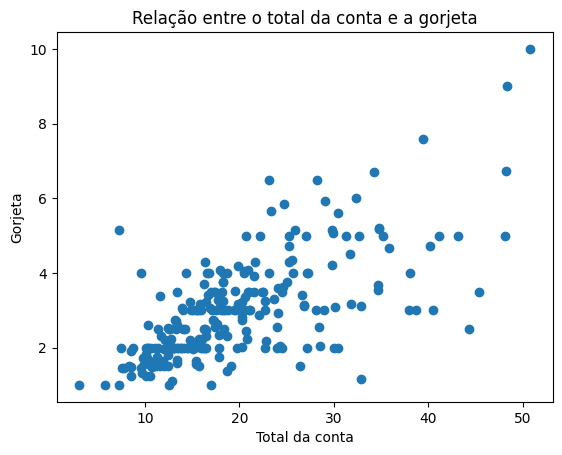

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df["total_bill"], df["tip"])

plt.xlabel("Total da conta")
plt.ylabel("Valor da Gorjeta")

plt.title("Relação entre o total da conta e a gorjeta")

plt.show()

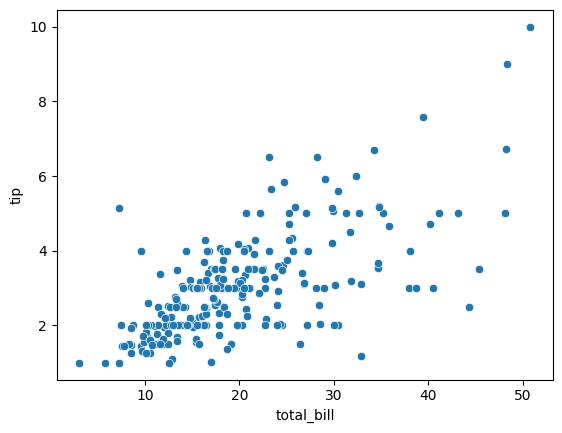

In [4]:
import seaborn as sns

sns.scatterplot(data=df, x="total_bill", y="tip")

plt.show()

In [5]:
import plotly.express as px

fig = px.scatter(df, x="total_bill", y="tip",color="day", title="Relação entre conta e gorjeta")

fig.show()
#

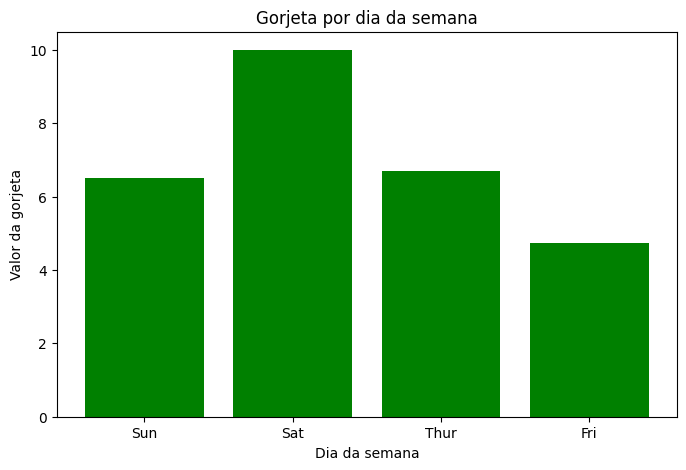

In [7]:
plt.figure(figsize=(8, 5))

plt.bar(df["day"], df["tip"], color="green")

plt.title("Gorjeta por dia da semana")

plt.xlabel("Dia da semana")
plt.ylabel("Valor da gorjeta")

plt.show()

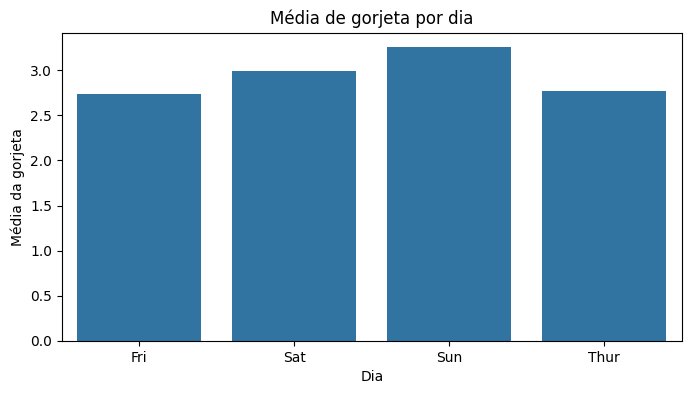

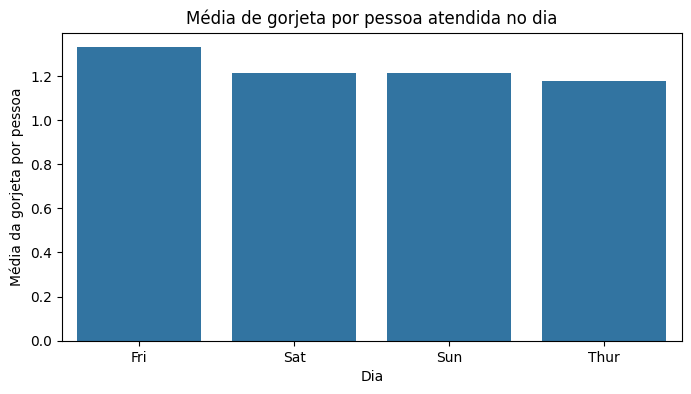

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# exemplo: df já possui as colunas tip, day e size

# 1) média de gorjeta por dia
media_tip_dia = df.groupby("day", as_index=False)["tip"].mean()

plt.figure(figsize=(8, 4))
sns.barplot(data=media_tip_dia, x="day", y="tip")
plt.title("Média de gorjeta por dia")
plt.xlabel("Dia")
plt.ylabel("Média da gorjeta")
plt.show()

# 2) média de gorjeta por pessoa atendida no dia
df["tip_por_pessoa"] = df["tip"] / df["size"]

media_tip_pessoa_dia = df.groupby("day", as_index=False)["tip_por_pessoa"].mean()

plt.figure(figsize=(8, 4))
sns.barplot(data=media_tip_pessoa_dia, x="day", y="tip_por_pessoa")
plt.title("Média de gorjeta por pessoa atendida no dia")
plt.xlabel("Dia")
plt.ylabel("Média da gorjeta por pessoa")
plt.show()

In [12]:
figure = px.scatter(
    df,
    x="total_bill",
    y="tip",
    color="day",
    size="size",
    hover_data=["sex", "time"],
    title="Relação entre conta e gorjeta"
)

fig.show()

In [14]:
pip install dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 53.3 MB/s eta 0:00:00


In [21]:
from dash import Dash, html, dcc
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    "Mes": ["Jan", "Fev", "Mar"],
    "Vendas": [100, 140, 180]
})

fig = px.line(df, x="Mes", y="Vendas", title="Vendas")

app = Dash(__name__)

app.layout = html.Div([
    html.H1("Dashboard de Vendas"),
    dcc.Graph(figure=fig)
])

app.run(debug=True, jupyter_mode="inline")

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: on


In [24]:
import time

inicio = time.perf_counter()

resultado = []
for i in range(1000):
    resultado.append(i)

fim = time.perf_counter()
print("Tempo da operação menos eficiente:", fim - inicio)



Tempo da operação menos eficiente: 0.0002698170001167455
Tempo da operação mais eficiente: 9.107599998969818e-05


In [23]:
import time

inicio = time.perf_counter()

resultado = list(range(1000))

fim = time.perf_counter()
print("Tempo da operação mais eficiente:", fim - inicio)

Tempo da operação mais eficiente: 0.00018341600025451044


# Sistema de Detecção de Fraudes

In [3]:
import pandas as pd

url ='https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Modelo desbalanceado
import pandas as pd

url ='https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'

df = pd.read_csv(url)

df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


In [5]:
# Feature Engineering
# Usando logaritmo para reduzir a discrepância entre os valores das transações (permitindo comparar valores muito grandes e muito pequenos)
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])

In [6]:
# Feature Engineering
# Transformando os dados para terem média igual a zero e DP igual a 1
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [8]:
# Feature Engineering
# Preparação dos dados para treinamento do modelo
from sklearn.model_selection import train_test_split

x = df.drop(["Class"], axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.3, random_state=42)

In [9]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.74       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



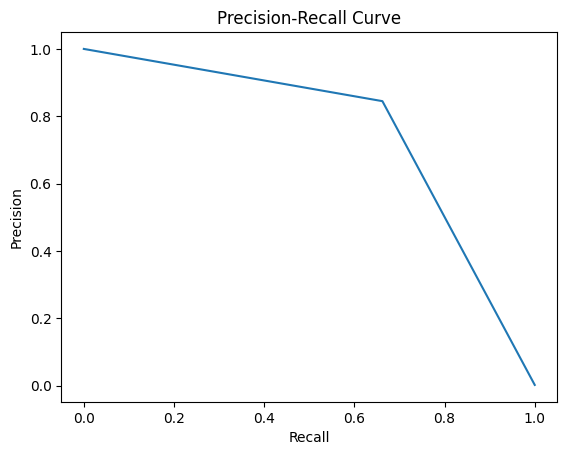

In [12]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [13]:
# Balanceamento de Dados
# Oversampling
fraudes = df[df["Class"] == 1]
nao_fraudes = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, nao_fraudes])

In [15]:
# Oversampling
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_smote, y_smote = smote.fit_resample(x, y)
#

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight="balanced", n_jobs=-1, random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [18]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [19]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

NameError: name 'y_probs' is not defined

In [20]:
# Modelo Avançado XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print(classification_report(y_test, y_pred))
#

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:49:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



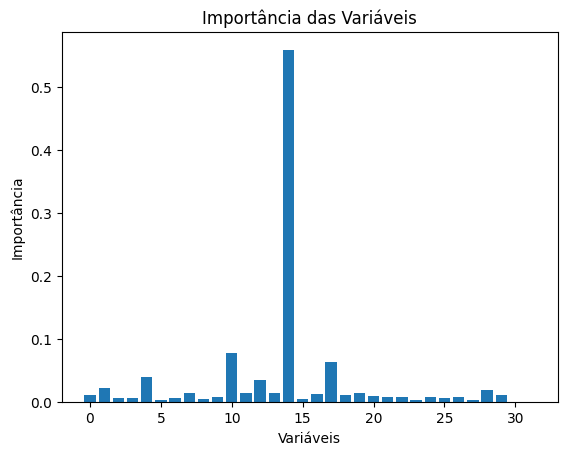

In [23]:
# importância das Variáveis
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das Variáveis")
plt.xlabel("Variáveis")
plt.ylabel("Importância")
plt.show()


In [27]:
# Ajuste de hiperparâmetros
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(X_train, y_train)

print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'max_depth': 3, 'n_estimators': 100}


In [29]:
# Explicabilidade (SHAP)
import shap

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.plots.waterfall(shap_values)

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (85443, 32)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.